# Miniproyecto 1: Clasificación de MRI con Redes Neuronales Convolucionales

**Curso:** Técnicas de Deep Learning  
**Objetivo:** Desarrollar un modelo de CNN para clasificar imágenes de resonancia magnética (MRI) en 4 categorías: Glioma, Meningioma, Pituitaria y Tejido Sano.

---

## Fase 1: Configuración y Carga de Datos

En esta fase se importan las librerías necesarias (preferiblemente PyTorch según la recomendación docente) y se establece la conexión con el dataset de 7023 imágenes.

In [151]:
DATA_DIR = '/Users/ricardo/Proyectos_Git/deep-learning-miniproyecto-1/Ricardo/archive'

In [5]:
os.getcwd()

'/Users/ricardo/Proyectos_Git/deep-learning-miniproyecto-1/Ricardo'

In [107]:
import tensorflow as tf
import numpy as np              # Librería para trabajar don datos matriciales
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow import keras    # Importar la APItensorflow.keras de TensorFlow
from tensorflow.keras import layers, models, Sequential

In [164]:
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


def load_images (ruta, val_size, test_size):
    
    data = tf.keras.utils.image_dataset_from_directory(
    ruta,
    image_size=(224,224),
    batch_size=None,
    color_mode="grayscale",
    seed = SEED,
    shuffle=False)

    dataset_size = data.cardinality().numpy()
    class_names = data.class_names

    data = data.shuffle(dataset_size, seed=42, reshuffle_each_iteration=False)

    val_size_aux  = int(val_size * dataset_size)
    test_size_aux = int(test_size * dataset_size)
    train_size = dataset_size - val_size_aux - test_size_aux
    
    
    train = data.take(train_size)
    val   = data.skip(train_size).take(val_size_aux)
    test  = data.skip(train_size + val_size_aux)


    train = train.map(preprocess)
    val   = val.map(preprocess)
    test  = test.map(preprocess)

    return data, class_names, train, val, test

In [165]:
data, nombres_clases, train, val, test = load_images(
    DATA_DIR,
    val_size=0.1,
    test_size=0.1
)

Found 7023 files belonging to 4 classes.


## Fase 2: Análisis Exploratorio de Datos (EDA)

Visualización de las categorías y verificación del balance de clases. 
*Rubric: Se requiere incluir figuras con mapas de colores adecuados y descripciones.*

In [ ]:
# Espacio para visualizar una muestra de cada clase
# y graficar la distribución de los datos (histograma de clases)

In [167]:
labels = []

for _, label in train:
    labels.append(label.numpy())

2026-04-25 21:01:14.982126: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [168]:
unique, counts = np.unique(labels, return_counts=True)

for label, count in zip(unique, counts):
    print(f"{nombres_clases[label]}: {count}")


glioma: 1310
healthy: 1607
meningioma: 1313
pituitary: 1389


## Fase 3: Preprocesamiento y Aumentación de Datos

Definición de las transformaciones para el pipeline de entrenamiento. Se recomienda:
1. Resize (ej. 224x224 para modelos tipo AlexNet/VGG).
2. Normalización.
3. Data Augmentation (ej. RandomHorizontalFlip, RandomRotation) para evitar el overfitting.

In [ ]:
# Definir transformaciones
# train_transforms = ...
# test_transforms = ...

# Cargar dataset y dividir en Train, Val y Test

## Fase 4: Diseño de la Arquitectura CNN

Implementación del modelo. Puede ser una arquitectura propia (basada en bloques Conv-Pool) o transferencia de aprendizaje (Fine-tuning).

In [169]:
BATCH_SIZE = 32

train = train.batch(BATCH_SIZE)
val   = val.batch(BATCH_SIZE)
test  = test.batch(BATCH_SIZE)

In [176]:
def load_model():
    
    model = Sequential()
    
    # Input
    model.add(layers.Input(shape=(224, 224, 1)))
    
    # Bloque 1
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))
    
    # Bloque 2
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))
    
    # Bloque 3
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))
    
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.BatchNormalization()) # También es muy útil en capas densas
    model.add(layers.Dropout(0.5))
    
    model.add(layers.Dense(4, activation='softmax'))
    
    model.summary()
    
    return model

In [177]:
model = load_model()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,780 (49.36 MB)

 Trainable params: 12,939,076 (49.36 MB)

 Non-trainable params: 704 (2.75 KB)

In [178]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [179]:
# TensorFlow
tf.random.set_seed(SEED)

In [180]:
resultsFit = model.fit(
    train,
    validation_data=val,
    epochs=10
)

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 44s 234ms/step - accuracy: 0.7249 - loss: 0.7996 - val_accuracy: 0.2721 - val_loss: 3.2716
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 42s 233ms/step - accuracy: 0.8409 - loss: 0.4552 - val_accuracy: 0.5812 - val_loss: 1.0725
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 42s 232ms/step - accuracy: 0.8882 - loss: 0.3103 - val_accuracy: 0.7821 - val_loss: 0.5733
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 42s 236ms/step - accuracy: 0.9180 - loss: 0.2266 - val_accuracy: 0.9074 - val_loss: 0.2770
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 43s 238ms/step - accuracy: 0.9397 - loss: 0.1682 - val_accuracy: 0.8433 - val_loss: 0.4276
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 42s 232ms/step - accuracy: 0.9575 - loss: 0.1286 - val_accuracy: 0.9131 - val_loss: 0.2550
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 42s 232ms/step - accuracy: 0.9658 - loss: 0.0944 - val_accuracy: 0.9188 - val_loss: 0.2312
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 42s 234ms/step - accuracy: 0.9779 - loss: 0

In [181]:
def visualization_history(resultsFit):
    """
    Esta función grafica las curvas de precisión a lo largo de las épocas de entrenamiento
    para el conjunto de prueba como el de validación.
    Parámetros:
    resultsFit = historial de entrenamiento de un modelo entensorflow.keras
    Salida:
    Gráfica de la precisión en validación y prueba.
    """
    # Llamado al entrono de la gráfica y fijar tamaño de visualización
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Graficar la presición de la historia en entrenamiento
    axes[0].plot(range(len(resultsFit.history['accuracy'])), resultsFit.history['accuracy'],
           '#5a2ff4', linestyle = "-", marker = "o",
           label='Precisión entrenamiento', lw = 3)

    # Graficar la presición de la historia en validación
    axes[0].plot(range(len(resultsFit.history['val_accuracy'])), resultsFit.history['val_accuracy'],  '#60d13e',
           label='Precisión validación', linestyle = '-', marker = 'o', lw = 3)
    
    # Umbral 90% de precisión 
    axes[0].plot(range(len(resultsFit.history['val_accuracy'])), 0.9*np.ones(len(resultsFit.history['val_accuracy'])), 
               'red', lw = 3, label = 'Umbral')
               
    # Títulos de los ejes
    axes[0].set_xlabel('Época',fontsize=16)
    axes[0].set_ylabel(r'Precisión',fontsize=16)
    axes[0].set_ylim(top=1) # Límite de la grafica
    axes[0].grid()      # Activar la cuadricula
    axes[0].legend(fontsize=14,loc = 'lower right')   # Establecer la legenda


    # Graficar la pérdida de la historia en entrenamiento
    axes[1].plot(range(len(resultsFit.history['loss'])), resultsFit.history['loss'],
           '#5a2ff4', linestyle = "-", marker = "o",
           label='Pérdida entrenamiento', lw = 3)

    # Graficar la presición de la historia en validación
    axes[1].plot(range(len(resultsFit.history['val_loss'])), resultsFit.history['val_loss'],  '#60d13e',
           label='Pérdida validación', linestyle = '-', marker = 'o', lw = 3)

    # Títulos de los ejes
    axes[1].set_xlabel('Época',fontsize=16)
    axes[1].set_ylabel(r'Pérdida',fontsize=16)
    axes[1].grid()      # Activar la cuadricula
    axes[1].legend(fontsize=14,loc = 'upper right')   # Establecer la legenda


    plt.tight_layout() # Ajusta automáticamente el diseño de la figura
    plt.show()

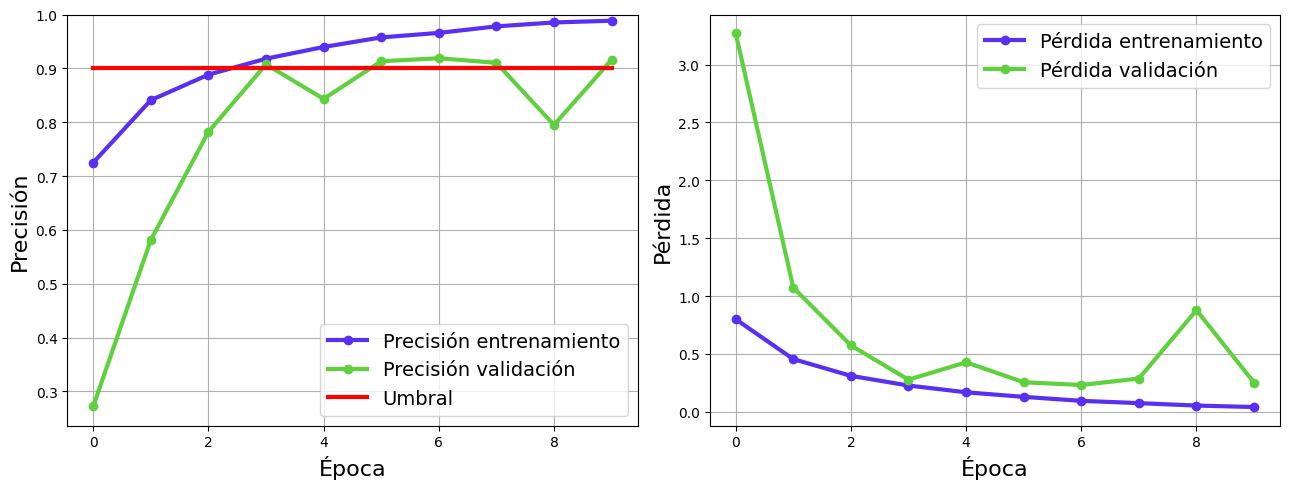

In [182]:
visualization_history(resultsFit)

In [183]:
test_loss, test_acc = model.evaluate(test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9430 - loss: 0.1865
Test Loss: 0.1865
Test Accuracy: 0.9430


2026-04-25 21:51:01.060201: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


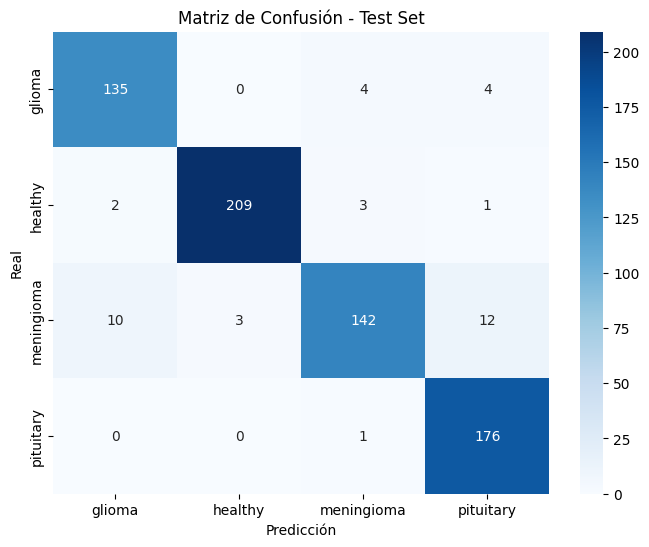

              precision    recall  f1-score   support

      glioma       0.92      0.94      0.93       143
     healthy       0.99      0.97      0.98       215
  meningioma       0.95      0.85      0.90       167
   pituitary       0.91      0.99      0.95       177

    accuracy                           0.94       702
   macro avg       0.94      0.94      0.94       702
weighted avg       0.94      0.94      0.94       702



In [185]:

y_true = []
y_pred = []

for images, labels in test:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Test Set')
plt.show()


print(classification_report(y_true, y_pred, target_names=class_names))

## Fase 5: Pipeline de Entrenamiento

Definición de la función de pérdida (`CrossEntropyLoss`) y el optimizador (`Adam`/`SGD`). Configuración del ciclo de entrenamiento con monitoreo de validación.

In [ ]:
# loss_fn = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)

# Implementar ciclo de entrenamiento (Epochs, Forward, Backward, Step)

## Fase 6: Resultados Cualitativos y Cuantitativos

Evaluación final del modelo en el conjunto de prueba.
*   **Cuantitativo:** Curvas de pérdida y precisión, matriz de confusión.
*   **Cualitativo:** Visualización de predicciones exitosas y fallidas.

In [ ]:
# Graficar curvas de entrenamiento
# Generar Matriz de Confusión
# Reportar métricas (Accuracy, Precision, Recall, F1)

## Fase 7: Discusión y Conclusiones

Análisis de los resultados obtenidos, identificación de fuentes de error y posibles mejoras para el informe final en formato IEEE.